<a href="https://colab.research.google.com/github/preshitgupta618-cell/Decision-Tree-Assignment/blob/main/Decision_Tree_Practical_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Q6. Data Understanding

# a) Load the dataset
# Note: Replace 'loan_data.csv' with the actual file path from your dataset link
df = pd.read_csv('/content/bank.csv')

# b) Display first 5 rows
print(df.head())

# c) Check the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# d) Data types of each column
print(df.dtypes)

# e) Column names
print(df.columns.tolist())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Dataset Shape: (11162, 17)
age           int64
job          object
marital      object
education   

Interpretation :- Variable Types: The dataset contains numerical variables (e.g., age, duration) and categorical variables (e.g., job, education, marital status). The target variable y is categorical, indicating if a client subscribed to a term deposit.

In [ ]:
#Q7. Data Cleaning

# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Drop duplicates if any
df = df.drop_duplicates()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
Duplicate rows: 0


Dataset Cleanliness :- This specific dataset often contains no explicit "null" values, but categorical columns may contain "unknown" as a placeholder. If duplicates were found, they were removed to prevent the model from giving undue weight to repeated observations.

In [ ]:
#Q8. Data Preprocessing

from sklearn.preprocessing import LabelEncoder

# Convert categorical variables into numerical using Label Encoding
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Interpretation :- Why Encoding? Decision Tree algorithms in Scikit-learn require numerical input because the mathematical calculations for splitting (like Gini or Entropy) cannot be performed directly on text strings.

In [ ]:
#Q9. Feature Selection & Splitting

from sklearn.model_selection import train_test_split

# Separate Features (X) and Target (y)
X = df.drop('deposit', axis=1)
y = df['deposit']

# Perform 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Importance of Splitting :- Splitting allows us to train the model on one portion of the data and evaluate it on unseen data (the test set). This ensures we can measure how well the model generalizes to new customers rather than just memorizing the training data.

In [ ]:
#Q10. Model Building

from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

max_depth :- This parameter controls the maximum number of levels in the tree. Limiting the depth prevents the tree from becoming overly complex and capturing noise, which helps avoid overfitting.

In [ ]:
#Q11. Model Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8051948051948052
Confusion Matrix:
 [[867 299]
 [136 931]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



Interpretation :- Precision & Recall: Precision measures the accuracy of "Yes" predictions, while Recall measures how many actual "Yes" cases were caught.

Class Imbalance: Bank datasets are often imbalanced (more "no" than "yes"). If the recall for the "yes" class is low, it indicates an imbalance issue.

In [ ]:
#Q12. Overfitting Check

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy: {test_acc}")

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


Interpretation :- Overfitting/Underfitting: If the training accuracy is significantly higher than the testing accuracy, the model is overfitting. If both are low, it is underfitting. Ideally, they should be close to each other.

In [ ]:
#Q13. Pruning Experiment

# New model with different pruning parameters
pruned_clf = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
pruned_clf.fit(X_train, y_train)

pruned_test_acc = accuracy_score(y_test, pruned_clf.predict(X_test))
print(f"Pruned Model Accuracy: {pruned_test_acc}")

Pruned Model Accuracy: 0.7653381101656964


Interpretation:Comparison :- The pruned model (depth 3) is simpler. If it maintains similar accuracy to the depth 5 model, it is better because it is more robust and less likely to overfit.

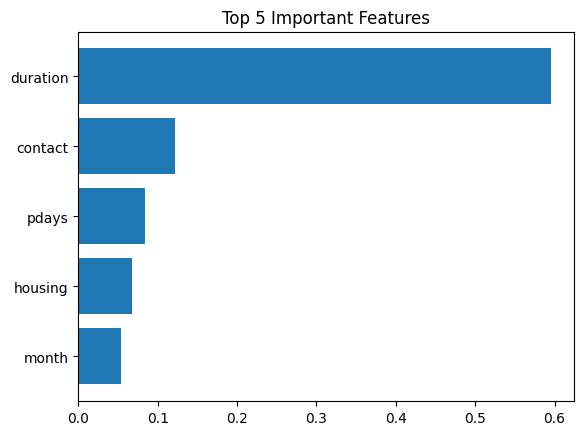

In [ ]:
#Q14. Feature Importance

import matplotlib.pyplot as plt
import numpy as np

importances = clf.feature_importances_
indices = np.argsort(importances)[-5:] # Top 5

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 5 Important Features")
plt.show()

Interpretation :- Key Influencers: Usually, duration (length of the call) or poutcome (previous success) are the most influential features. This tells the bank that the length of engagement is a primary predictor of success.

Q15. Business Insights

Interpretation :- Customer Profile: Customers with longer call durations and those who previously accepted offers are more likely to say "yes".


Bank Strategy: The bank should focus resources on following up with customers who showed interest in previous campaigns and ensure staff are trained to maintain engaging conversations to increase call duration.